# Lab 7: Simple Linear Regression
In this tutorial, we will walk through different steps of linear regression modeling introduced in the lecture. We will be working on __The World Happiness Dataset__ from Kaggle website:<br>
https://www.kaggle.com/unsdsn/world-happiness <br>
You will need to modify and combine these steps into several functions for the Assignment.

In [1]:
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt 
%matplotlib inline
import scipy.optimize as so
import pandas as pd 
import numpy as np
import seaborn as sns

## Import the dataset

In [2]:
# we will be workin on the dataset from 2019
df = pd.read_csv('2019.csv')
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [3]:
# overal inspection of the dataset
## the first 5 rows

## print out the number of columns
print(f"the number of observations is {len(df.index)}")
print(f"the number of variables is {len(df.columns)}")
print(df.columns)

the number of observations is 156
the number of variables is 9
Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')


## Relationship between Happiness score and other variables
Here, we will be using scatter plots to have a quick look at the relationship between Happiness score of countries and other variables reported in the dataset. <br>
What do you think about the relationship between the happiness score and the variable on the y-axis?

<Axes: xlabel='Generosity', ylabel='Score'>

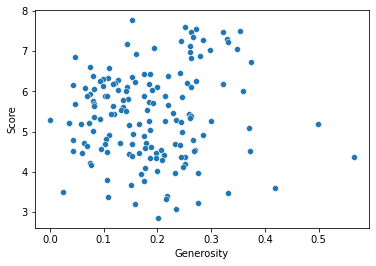

In [4]:
# score vs Generocity
sns.scatterplot(x = 'Generosity', y = 'Score', data = df)

<Axes: xlabel='Social support', ylabel='Score'>

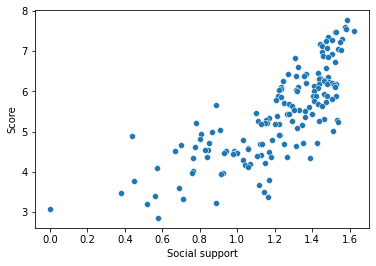

In [5]:
# Social support vs Score
sns.scatterplot(x = "Social support", y = "Score", data = df)

<Axes: xlabel='Healthy life expectancy', ylabel='Score'>

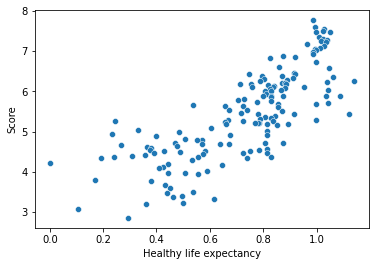

In [6]:
# Healthy life expectancy vs Score
sns.scatterplot(x = "Healthy life expectancy", y = "Score", data = df)

<Axes: xlabel='Freedom to make life choices', ylabel='Score'>

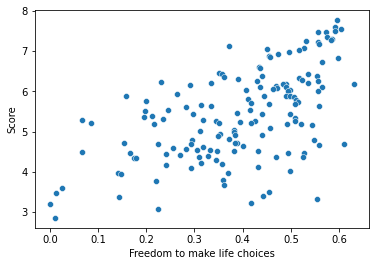

In [7]:
# Freedom to make life choices vs Score
sns.scatterplot(x = "Freedom to make life choices", y = "Score", data = df)

<Axes: xlabel='Perceptions of corruption', ylabel='Score'>

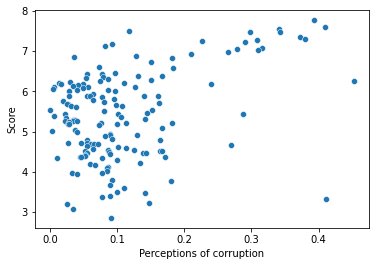

In [8]:
# Perceptions of corruption vs Score
sns.scatterplot(x = "Perceptions of corruption", y = "Score", data = df)

## Fit a linear regression line "by hand"
Let's take a closet look at the relationship between Happiness Score and Healthy life expectancy.<br>
We will fit a linear regression line to the data.<br>
The formula: _y = b0 + b1*x_

In [9]:
# define x and y
y1 = df["Score"].values
x1 = df["Healthy life expectancy"].values
print(type(x1))

<class 'numpy.ndarray'>


In [10]:
# Regression formula
## Don't forget printting the type and size of arrays 
def simpleRegPredict(b, x):
    """
    b = [b0, b1] # a (list) containing the parameters defining the line
    x is a numpy array. the regressor
    """
    yp = b[0] + b[1]*x
    
    return yp

In [11]:
yp1 = simpleRegPredict(b = [0.1, 2], x = x1)
print(type(yp1))
print(yp1.shape)
print(yp1)

<class 'numpy.ndarray'>
(156,)
[2.072 2.092 2.156 2.152 2.098 2.204 2.118 2.152 2.178 2.132 2.172 2.026
 2.158 2.124 2.092 2.098 2.074 2.072 1.848 1.94  1.75  2.098 1.822 2.19
 1.928 1.94  1.592 1.69  1.842 2.224 1.92  1.704 1.882 2.382 1.678 2.178
 1.842 1.862 1.526 1.868 1.612 1.736 1.782 2.006 1.77  1.616 1.862 1.75
 2.184 1.836 1.716 1.756 1.724 2.172 1.848 1.762 1.696 2.276 1.756 1.558
 1.512 1.756 1.654 2.184 1.808 2.098 1.17  1.552 1.414 1.808 1.578 1.446
 1.842 1.536 1.928 2.344 1.658 1.79  1.716 1.756 1.678 2.098 1.434 1.776
 0.59  1.546 1.414 1.67  1.664 1.638 1.73  1.42  1.886 1.802 1.308 0.762
 1.73  1.072 0.564 1.454 1.73  0.894 1.116 1.242 1.202 1.038 1.848 1.71
 1.374 1.444 1.242 0.636 1.054 0.832 0.86  1.73  1.67  0.85  1.604 0.956
 1.262 1.078 0.88  1.73  1.546 1.248 0.814 0.716 0.584 1.762 1.21  0.484
 1.578 1.164 0.1   0.986 1.388 0.952 0.92  1.276 0.986 1.11  1.21  0.436
 0.86  0.966 0.998 1.176 0.98  1.09  1.026 1.328 1.098 0.822 0.31  0.69 ]


### Playing around with regression coefficients
We'll be using the simpleregPredict function to predict y-values

#### 1. do the scatter plot
plot _Healthy life expectancy_ against _Score_

<Axes: xlabel='Healthy life expectancy', ylabel='Score'>

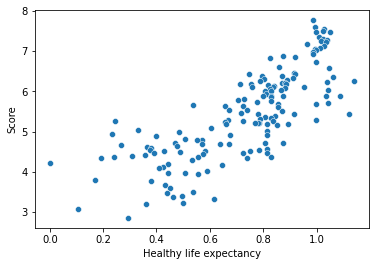

In [12]:
# create a figure object and do the scatterplot
sns.scatterplot(x = "Healthy life expectancy", y = "Score", data = df)

#### 2. plot a linear regression line 
We will do this step for different regression coefficient arrays

In [13]:
def plotPrediction(b,x,y,predictFcn=simpleRegPredict):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    ax.scatter(x,y)
    xp = np.linspace(min(x),max(x),num=50)
    yp = predictFcn(b,xp)
    return ax.plot(xp,yp,'r')

#### 3. plot the regression line for the two regression models on top of the scatter plot
* when plotting the linear regression, we will create a new "x" array and use it for plotting

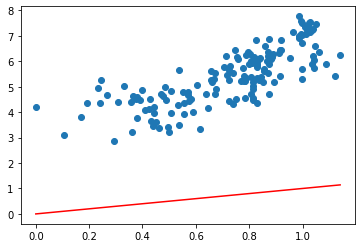

In [14]:
# examine different regression coefficients

## create an array for x
x_simulated = np.linspace(min(x1), max(x1), num = len(x1))
# print(type(x_simulated))
# print(x_simulated.shape)
# print(x_simulated)

## the first b
## model 1:
b1 = [0, 1]
yp1 = simpleRegPredict(b = b1, x = x_simulated)
# print(type(yp1))
# print(yp1)
plotPrediction(b1,x1,y1,predictFcn=simpleRegPredict)


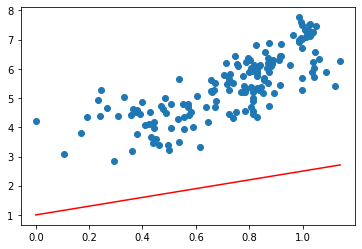

In [15]:
## the second b :)
b2 = [1, 1.5]
yp2 = simpleRegPredict(b = b2, x = x_simulated)
# print(yp2)
plotPrediction(b2,x1,y1,predictFcn=simpleRegPredict)

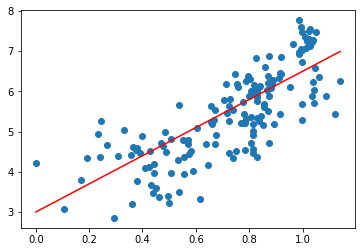

In [16]:
b3 = [3, 3.5]
plotPrediction(b3,x1,y1,predictFcn=simpleRegPredict)

### Define the _Residual Sum of Squares_ loss function and its derivative
We can go on forever, playaround with the coefficients and look at the line! But that's neither efficient nor optimal! So we will take on another approach!<br>
We will define a __loss__ function and try to find the coefficients for which this __loss__ function becomes minimum. The function will take in the regression coefficient array, x, and y and returns both the __rss__ and __gradient__ (vector of partial derivatives).
Then it should do the following steps:
* use b and x as inputs to the linear regression function and get the predicted y values
* Calculate the residual sum of squares
* calculate the derivatives

In [31]:
# a pseudo code for the function:
# use b (parameters of the regression model) and x to predict the y values
# calculate the residuals (difference between the real and predicted y values)
# calculate the derivatives with respect to each parameter (regression coefficient)
yp3 = simpleRegPredict(b3, x1)
res = y1 - yp3
res2 = res**2
rss = sum(res2)
print(rss)

77.9958295


In [32]:
yp1 = simpleRegPredict(b1, x1)
res = y1 - yp1
res2 = res**2
rss = sum(res2)
print(rss)

3555.4587670000024


In [33]:
yp2 = simpleRegPredict(b2, x1)
res = y1 - yp2
res2 = res**2
rss = sum(res2)
print(rss)

1833.4556454999993


#### Calculate the derivatives of rss with respect to each coefficients
As we are trying to find the parameters for which the __loss__ function is minimized, we will take the derivative of the __loss__ function with respect to each coef.<br>
Lets derive the derivatives:<br>
y_predicted = b0+b1*x

RSS = sum((y1 - y_predicted)**2)

RSS = sum((y1 - (b0 + b1*x))**2)

In [20]:
# first, initialize the derivative array
## as we only have two parameters (regression coefficients: intercept and slope):
deriv = [0, 0]
b3 = [3, 3.5]
# calculate the residuals
res = y1 - simpleRegPredict(b3, x1)
res2 = res**2
rss = sum(res2)
# RSS, derv = simpleRegLossRSS(b,x,y)
   

# derivative of the loss function with respect to b0 (the intercept)
deriv[0] = -2*sum(res) 

# derivative of the loss function with respect to b1 (the slope)
deriv[1] = -2*sum(res*x1)
print(deriv[0],deriv[1])

40.952000000000034 28.148760000000006


In [21]:
# define loss function
def simpleRegLossRSS(b,x,y):
    predY = simpleRegPredict(b,x)
    res = y-predY
    rss = sum(res**2)
    deriv = np.zeros(2)
    deriv[0]=-2*sum(res)
    deriv[1]=-2*sum(res*x)
    return (rss,deriv)

In [34]:
RSS, gradient = simpleRegLossRSS(b3,x1,y1)
print(RSS)
print(gradient)

77.9958295
[40.952   28.14876]


In [35]:
simpleRegLossRSS(b3,x1,y1)

(77.9958295, array([40.952  , 28.14876]))

#### Increase the parameter or decrease it?
Based on the derivatives would you increase the parameter or decrease it?

In [24]:
# Trying out different bs
b4 = [3, 3.35]
RSS, deriv_array = simpleRegLossRSS(b4,x1,y1)
print(RSS)
print(deriv_array)

75.82415051500003
[7.0106    0.8069598]


### Using scipy.optimize.minimize to fit the linear regression line
Again, we can go on and on and try out different parameters to see which one is giving us the best answer (is the __loss__ getting smaller and smaller as you change the parameters?) <br>
Scipy provides you with a method to minimize the loss function. Make sure you go through the documentation:<br>
https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html <br>
Make sure you go through the document and understand the output fields

In [25]:
# making sure I have imported scipy optimize
import scipy.optimize as so

In [26]:
# define the loss function that scipy.optimize will be using to fit the model
loss_fcn = simpleRegLossRSS

# initialize the coefficients
b0       = np.zeros(2)
RESULT   = so.minimize(loss_fcn, b0, args=(x1, y1), jac=True)

# print out the result
RESULT

      fun: 75.2420032886066
 hess_inv: array([[ 0.03214725, -0.03990677],
       [-0.03990677,  0.05502533]])
      jac: array([-1.77635684e-15,  9.99200722e-15])
  message: 'Optimization terminated successfully.'
     nfev: 7
      nit: 5
     njev: 7
   status: 0
  success: True
        x: array([2.80683162, 3.58536714])

In [27]:
b = RESULT.x
print(b)

[2.80683162 3.58536714]


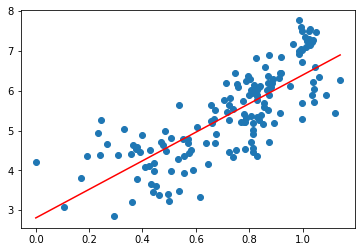

In [28]:
# scatter plot and the regression line
plotPrediction(b,x1,y1,predictFcn=simpleRegPredict)

### Calculating R2 
R2 = 1 - (RSS/TSS) <br>
* TSS is the total sum of squares
* RSS is the residual sum of squares

In [29]:
rss = RESULT.fun
rss

75.2420032886066

In [37]:
# lets calculate the R2 with the best model

# As you don't have the function for getting the loss and derivative here,
# to show you how it works, I am going through the following steps
## get the predicted values from the model 

## calculate the RSS, TSS 


RSS = sum((y1 - simpleRegPredict(RESULT.x, x1))**2)
## calculate total sums of squares
TSS = sum((y1 - np.mean(y1))**2)


## calculate R2
R2 = 1 - (RSS/TSS)
print(R2)


0.6082177264725289


What does a $R^2$ of 0.61 mean? 

### This is just a check to see if our code is working fine (delete): 
You can skip this in the lab - sklearn won't be allowed until DS3000. 

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lin_reg=LinearRegression()
X = x1.reshape(-1, 1)
X.shape

(156, 1)

In [ ]:
lin_reg.fit(X, y1)

LinearRegression()

In [ ]:
lin_reg.score(X, y1)

0.608217726472529